# Introdução à otimização: Exercícios e Problemas Computacionais

**Matheus Venancio Moreira Sales**

## TC.1

Selecione um artigo científico, de evento ou periódico, que aborde um problema de otimização. Esse artigo deve, necessariamente estar relacionado às áreas de atuação do INPE ou ao seu tema de tese/dissertação. Leia o artigo e discuta:

**Artigo escolhido:** LUO, Z.; XU, H.; XING, Y.; ZHU, C.; JIAO, Z.; CUI, C. *Forest Fire Monitoring UAV System Using Forest PSO-GA Algorithm*. Preprints.org, 2025. Preprint, não revisado por pares. DOI: [10.20944/preprints202502.0436.v1](https://doi.org/10.20944/preprints202502.0436.v1).

### a. Qual problema está sendo resolvido

O problema central é a detecção precoce e a localização rápida e precisa do foco de incêndios florestais quando a sua posição é desconhecida, situação típica do estágio inicial do fogo. Para isso, o estudo usa um enxame de Veículos Aéreos Não Tripulados (VANTs) com sensores de fumaça: a concentração medida por cada VANT serve de sinal para guiar o enxame até a fonte. Em termos de otimização, trata-se de encontrar a posição em que esse sinal é máximo, no menor tempo possível, sob a influência do vento e do relevo.

### b. Em qual contexto a otimização está sendo efetuada e qual técnica é utilizada

**Contexto:** A otimização é efetuada no contexto de busca de alvos e planejamento de rotas para enxames de VANTs no monitoramento de incêndios florestais.

**Técnica:** Os autores propõem uma metaheurística híbrida denominada Forest PSO-GA. Ela integra a Otimização por Enxame de Partículas (PSO) com operações de cruzamento, mutação e seleção de um Algoritmo Genético (GA), para evitar ótimos locais. O PSO é adaptado ao ambiente florestal com um peso de inércia adaptativo e com termos de vento e de declividade do terreno na equação de velocidade. O desempenho é comparado com os algoritmos APSO, AFSA e PSO-PID.

### c. Quais as variáveis de projeto/decisão do problema

As variáveis de decisão são as posições dos VANTs no plano da área de busca, $(x_i, y_i)$, com $i = 1, \dots, N$, em que $N$ é o número de VANTs do enxame. A função objetivo depende apenas dessas coordenadas. A velocidade $V_i$ de cada VANT não é uma variável do problema, e sim a variável auxiliar que o PSO usa para atualizar as posições a cada iteração.

### d. Como uma solução candidata é representada na obtenção da solução ótima

Cada solução candidata é representada individualmente por uma partícula, que corresponde a um único VANT do enxame. Esta partícula carrega consigo um vetor de posição e um vetor de velocidade no plano da área de busca. O conjunto de VANTs forma uma "população" de soluções candidatas que trocam informações (hibridização) e atualizam iterativamente suas posições para se moverem de forma coordenada em direção à origem do fogo.

### e. Qual o critério de avaliação da solução (i.e., função objetivo)

O critério de avaliação é baseado na função de detecção do sinal alvo, que mede a concentração de fumaça no ambiente. O objetivo do algoritmo é maximizar o valor do sinal alvo $f_i(x_i, y_i) = G(x_i, y_i) - \Delta G$ (onde $G$ é a concentração lida pelo sensor do VANT), pois concentrações maiores indicam uma proximidade maior à fonte do incêndio. A aptidão compara os valores de todos os VANTs, $\arg\max(f_1, \dots, f_N)$, para identificar a melhor posição de cada partícula e a melhor do enxame a cada instante.

### f. Qual/quais os critérios de parada utilizados

- **Tempo máximo:** cada experimento é interrompido ao atingir o tempo máximo de iteração de 330 minutos.
- **Convergência do alvo:** a busca é considerada concluída quando o valor do sinal-alvo atinge um limiar, o que indica que a fonte do fogo foi localizada. O "tempo de busca" usado para comparar os algoritmos é justamente o tempo necessário para atingir esse limiar.

### g. Quais as restrições do problema de otimização e como elas são tratadas

As principais restrições do problema modelado são o consumo de energia e as limitações impostas pelo relevo (declividade do terreno), já que subir encostas íngremes exige mais energia dos VANTs: o consumo é tratado como proporcional ao gradiente de elevação e à velocidade do VANT.

**Como são tratadas:** por penalidade e por modificações no próprio algoritmo:

- se a declividade ultrapassar o limite de segurança de $30^\circ$, um termo de penalidade é somado à função objetivo, forçando o VANT a fazer um desvio (o artigo não apresenta a expressão dessa penalidade);
- a equação de atualização de velocidade do PSO (Eq. 12) inclui um termo com o gradiente do terreno, extraído do DEM, que afasta os VANTs de encostas íngremes;
- o peso de inércia é reduzido para as partículas de maior consumo, e a seleção do algoritmo genético prioriza indivíduos de baixo consumo.

## TC.2

Para cada uma das seguintes áreas do conhecimento, exemplifique um problema de otimização.

### e. Social, com foco na distribuição de alimentos

O problema consiste em otimizar a rota e a alocação de mantimentos a partir de centros de distribuição (bancos de alimentos) para múltiplos centros comunitários ou abrigos em situação de vulnerabilidade, visando atender à demanda com o menor custo logístico e tempo possível.

#### i. Função Objetivo

A função objetivo visa minimizar o custo total de transporte (que pode ser traduzido em quilômetros rodados, tempo total de entrega ou emissão de poluentes), ponderado pelas prioridades de urgência das comunidades atendidas:

$$
\min f(\vec{x}) = \sum_{i=1}^{m} \sum_{j=1}^{n} c_{ij} \cdot x_{ij}
$$

Onde:

- $c_{ij}$ representa o custo logístico entre o centro de distribuição $i$ e o destino $j$.
- $x_{ij}$ é a quantidade de alimentos enviada do centro $i$ para o destino $j$.

#### ii. Espaço de Busca ($\mathcal{X}$)

O espaço de busca engloba todas as combinações viáveis de alocações de volumes de alimentos e sequências de rotas que os veículos de entrega podem realizar. Ele é composto por variáveis contínuas (quantidades de toneladas alocadas) e discretas/binárias (definição de quais rotas e estradas serão utilizadas).

#### iii. Restrições ($\mathcal{X}$)

As restrições modelam os limites físicos, logísticos e orçamentários do problema:

- **Atendimento da Demanda:** A quantidade de alimentos recebida por cada abrigo $j$ deve ser maior ou igual à sua necessidade mínima de subsistência:

  $$
  \sum_{i} x_{ij} \ge \text{Demanda}_j
  $$

- **Capacidade dos Centros de Distribuição:** O total de mantimentos expedidos por um centro $i$ não pode exceder o seu estoque disponível:

  $$
  \sum_{j} x_{ij} \ge \text{Estoque}_i
  $$

- **Capacidade da Frota:** A carga transportada por cada veículo não pode ultrapassar a sua capacidade máxima de peso e volume.

- **Não-negatividade:** As quantidades alocadas devem ser estritamente não-negativas ($x_{ij} \ge 0$).

#### iv. Critério(s) de Parada

Como problemas de roteamento e alocação logística de grande escala costumam ser complexos, os critérios de parada mais comuns englobam:

- **Convergência Matemática:** O algoritmo atinge a tolerância ótima estipulada (comprovação de que não há rotas alternativas com custos inferiores).
- **Limite de Tempo ou Iterações:** O solver é interrompido após esgotar o tempo máximo de processamento computacional permitido (por exemplo, 30 minutos de execução).

## PC.3

Para a seguinte função objetivo, conhecida como função de Rastrigin, implemente cada um dos métodos de otimização citados e compare o desempenho com uma busca aleatória. Discuta os desempenhos obtidos e mostre a trajetória das melhores soluções ao longo das iterações através de segmentos de reta sobre as curvas de nível das funções.

$$
f(x, y) = 20 + x^2 + y^2 - 10 \left[ \cos(2\pi x) + \cos(2\pi y) \right]
$$

### a. Nelder-Mead

#### Mecanismo local sem derivadas

O método de Nelder-Mead (1965) é uma busca local que não usa derivadas: ele só compara
valores da função objetivo nos vértices de um *simplex*, que em duas dimensões é um
triângulo com os vértices *melhor*, *bom* e *pior*. A cada iteração, o pior vértice é
trocado por um ponto novo, calculado em relação ao centroide $c$ dos outros dois, e o
triângulo se desloca e se deforma em direção a valores menores da função. Por isso é
indicado quando a derivada não existe ou é difícil de calcular. Como é local e
determinístico, converge para o mínimo da região onde o simplex inicial foi colocado e
não tem mecanismo para escapar de mínimos locais.

In [27]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image

def rastrigin(x, y):
    return 20 + x**2 + y**2 - 10 * (math.cos(2 * math.pi * x) + math.cos(2 * math.pi * y))

In [28]:
# BUSCA ALEATÓRIA

def busca_aleatoria_anim(limites, num_iteracoes=60):
    melhor_posicao = None
    melhor_valor = float('inf')
    historico_melhores = []
    
    for _ in range(num_iteracoes):
        x = random.uniform(limites[0], limites[1])
        y = random.uniform(limites[0], limites[1])
        valor = rastrigin(x, y)
        
        if valor < melhor_valor:
            melhor_valor = valor
            melhor_posicao = (x, y)
        
        if melhor_posicao is not None:
            historico_melhores.append(melhor_posicao)

    historico_melhores.append(melhor_posicao)
    return melhor_posicao, melhor_valor, historico_melhores


#### Quando realizar reflexão, expansão, contração e redução

A cada iteração, calcula-se primeiro o ponto refletido $R$. O movimento realizado depende de como $R$ se compara com os vértices atuais. Cada movimento está descrito a seguir, junto com o seu código.

Os coeficientes são os valores padrão: $\alpha$ = 1 (reflexão), $\gamma$ = 2 (expansão), $\rho$ = 0,5 (contração) e $\sigma$ = 0,5 (redução).

<p align="center">
  <img src="11081_2021_9620_Fig2_HTML.png" width="70%" alt="Os quatro movimentos do simplex no método de Nelder-Mead: reflexão, expansão, contração e redução">
</p>

##### Reflexão

- **Movimento:** o pior vértice $P$ é espelhado em relação ao centroide $c$ dos outros dois: $R = c + \alpha (c - P)$.
- **Lógica:** é o primeiro movimento testado em toda iteração. $R$ entra no lugar do pior vértice quando é melhor que o *bom*, mas não supera o *melhor*.

In [ ]:
# REFLEXÃO

def reflexao(centroide, pior, alfa):
    rx = centroide[0] + alfa * (centroide[0] - pior[0])
    ry = centroide[1] + alfa * (centroide[1] - pior[1])
    return (rx, ry)

##### Expansão

- **Movimento:** testa-se um ponto mais distante na mesma direção da reflexão: $E = c + \gamma (R - c)$.
- **Lógica:** é realizada quando $R$ é melhor que o *melhor*. $E$ é aceito se for melhor que $R$; caso contrário, fica-se com $R$.

In [ ]:
# EXPANSÃO

def expansao(centroide, refletido, gama):
    ex = centroide[0] + gama * (refletido[0] - centroide[0])
    ey = centroide[1] + gama * (refletido[1] - centroide[1])
    return (ex, ey)

##### Contração

- **Movimento:** testa-se um ponto mais próximo do centroide: $C = c + \rho (R - c)$, se $R$ ainda é melhor que o *pior*, ou $C = c + \rho (P - c)$, caso contrário.
- **Lógica:** é realizada quando $R$ é pior ou igual ao *bom*. $C$ é aceito se trouxer melhora.

In [ ]:
# CONTRAÇÃO

def contracao(centroide, ponto, rho):
    # 'ponto' é o refletido (se ele ainda é melhor que o pior) ou o próprio pior vértice
    ctx = centroide[0] + rho * (ponto[0] - centroide[0])
    cty = centroide[1] + rho * (ponto[1] - centroide[1])
    return (ctx, cty)

##### Redução

- **Movimento:** os vértices *bom* e *pior* andam em direção ao *melhor* $M$: $v \leftarrow M + \sigma (v - M)$. O triângulo encolhe.
- **Lógica:** é realizada quando nem a contração traz melhora.

In [ ]:
# REDUÇÃO

def reducao(melhor, vertice, sigma):
    vx = melhor[0] + sigma * (vertice[0] - melhor[0])
    vy = melhor[1] + sigma * (vertice[1] - melhor[1])
    return (vx, vy)

#### Algoritmo completo

A cada iteração, os vértices são ordenados em *melhor*, *bom* e *pior*, calcula-se o centroide dos dois melhores e escolhe-se o movimento conforme o valor da função no ponto refletido.

In [ ]:
# NELDER-MEAD

def nelder_mead(ponto_inicial, passo=0.3, num_iteracoes=60):
    alfa, gama, rho, sigma = 1.0, 2.0, 0.5, 0.5
    x0, y0 = ponto_inicial
    simplex = [(x0, y0), (x0 + passo, y0), (x0, y0 + passo)]
    historico_simplex = []
    
    for iteracao in range(num_iteracoes):
        historico_simplex.append(list(simplex))
        
        simplex.sort(key=lambda pt: rastrigin(pt[0], pt[1]))
        melhor, bom, pior = simplex[0], simplex[1], simplex[2]
        f_melhor, f_bom, f_pior = rastrigin(melhor[0], melhor[1]), rastrigin(bom[0], bom[1]), rastrigin(pior[0], pior[1])
        
        cx = (melhor[0] + bom[0]) / 2.0
        cy = (melhor[1] + bom[1]) / 2.0
        centroide = (cx, cy)
        
        # Reflexão: primeiro movimento testado em toda iteração
        refletido = reflexao(centroide, pior, alfa)
        f_r = rastrigin(refletido[0], refletido[1])
        
        if f_melhor <= f_r < f_bom:
            simplex[2] = refletido
            continue
            
        # Expansão: o refletido superou o melhor vértice
        if f_r < f_melhor:
            expandido = expansao(centroide, refletido, gama)
            if rastrigin(expandido[0], expandido[1]) < f_r:
                simplex[2] = expandido
            else:
                simplex[2] = refletido
            continue
            
        # Contração: o refletido é pior ou igual ao bom
        if f_r >= f_bom:
            if f_r < f_pior:
                contraido = contracao(centroide, refletido, rho)
                if rastrigin(contraido[0], contraido[1]) <= f_r:
                    simplex[2] = contraido
                    continue
            else:
                contraido = contracao(centroide, pior, rho)
                if rastrigin(contraido[0], contraido[1]) < f_pior:
                    simplex[2] = contraido
                    continue
                    
        # Redução: nem a contração trouxe melhora
        simplex[1] = reducao(melhor, bom, sigma)
        simplex[2] = reducao(melhor, pior, sigma)

    historico_simplex.append(list(simplex))
    simplex.sort(key=lambda pt: rastrigin(pt[0], pt[1]))
    return simplex[0], rastrigin(simplex[0][0], simplex[0][1]), historico_simplex

#### Simplex inicial

- **O que é:** o conjunto de vértices com que a busca começa. A partir do ponto inicial $(x_0, y_0)$, os outros dois vértices são criados deslocando cada coordenada de um valor $s$, o tamanho do simplex inicial: $(x_0 + s,\ y_0)$ e $(x_0,\ y_0 + s)$.
- **Como funciona:** o tamanho $s$ só é usado para montar o simplex inicial; depois, o simplex muda de tamanho sozinho com as expansões, contrações e reduções. Ele define o alcance dos primeiros movimentos: quanto maior o simplex inicial, mais longe do ponto inicial caem os outros dois vértices. Se eles caírem em pontos melhores, perto de outro mínimo, o simplex é levado para lá; se caírem em pontos piores, o simplex encolhe de volta em direção ao ponto inicial.

**Exemplo:** mesmo ponto inicial (0,1; 0,1) e 30 iterações, mudando apenas o tamanho do simplex inicial.

<p align="center">
  <img src="otimizacao_comparativa%280.1%200.1%29passo0.2.gif" width="49%" alt="Nelder-Mead com simplex inicial de tamanho 0,5">
  <img src="otimizacao_comparativa%280.1%2C%200.1%29passo0.9.gif" width="49%" alt="Nelder-Mead com simplex inicial de tamanho 0,9">
</p>

- **Simplex inicial de tamanho 0,5 (à esquerda):** os outros dois vértices caem logo depois das cristas que cercam o vale central, em pontos piores que o inicial. Nem a contração melhora, então ocorre uma redução: o simplex encolhe em direção ao ponto inicial, volta para o vale central, e o método converge para o ótimo global $(0, 0)$, com valor 0.
- **Simplex inicial de tamanho 0,9 (à direita):** os outros dois vértices caem perto de outros mínimos, $(1, 0)$ e $(0, 1)$, em pontos melhores que o inicial. O ponto inicial passa a ser o pior vértice e é refletido para longe da origem, e o método converge para o mínimo local (0,995; 0,995), com valor 1,99.

In [30]:
# GERAÇÃO DA ANIMAÇÃO

def executar_e_plotar_animacao():
    limites = [-5.12, 5.12]
    ponto_inicial = (0.3, 0.1)
    iteracoes = 30
    
    # Executa ambos os algoritmos
    _, _, hist_simplex = nelder_mead(ponto_inicial, num_iteracoes=iteracoes)
    _, _, hist_ba = busca_aleatoria_anim(limites, num_iteracoes=iteracoes)
    
    # Configuração da Figura
    fig, ax = plt.subplots(figsize=(10, 8))
    x_grid = np.linspace(limites[0], limites[1], 200)
    y_grid = np.linspace(limites[0], limites[1], 200)
    X, Y = np.meshgrid(x_grid, y_grid)
    Z = 20 + X**2 + Y**2 - 10 * (np.cos(2 * np.pi * X) + np.cos(2 * np.pi * Y))
    
    ax.contour(X, Y, Z, levels=40, cmap='viridis', alpha=0.5)
    ax.plot(0, 0, 'k*', markersize=15, label='Ótimo Global (0,0)')
    
    # Cria os objetos visuais que serão atualizados no GIF
    linha_simplex, = ax.plot([], [], 'r-o', lw=2, markersize=6, label='Nelder-Mead (Local)')
    linha_ba, = ax.plot([], [], 'b--x', lw=1.5, markersize=5, label='Busca Aleatória (Global)')
    
    ax.set_xlim(limites)
    ax.set_ylim(limites)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Inicialização dos dados limpos
    def init():
        linha_simplex.set_data([], [])
        linha_ba.set_data([], [])
        ax.set_title('Otimização: Inicializando...')
        return linha_simplex, linha_ba
        
    # Atualização a cada frame
    def update(frame):
        # 1. Atualiza o Triângulo do Nelder-Mead
        simplex_atual = hist_simplex[frame]
        xs_nm = [pt[0] for pt in simplex_atual] + [simplex_atual[0][0]]
        ys_nm = [pt[1] for pt in simplex_atual] + [simplex_atual[0][1]]
        linha_simplex.set_data(xs_nm, ys_nm)
        
        # 2. Atualiza a Trajetória da Busca Aleatória
        # Pega o histórico desde a iteração 0 até o frame atual para desenhar o segmento de reta
        trajetoria_ba = hist_ba[:frame+1]
        xs_ba = [pt[0] for pt in trajetoria_ba]
        ys_ba = [pt[1] for pt in trajetoria_ba]
        linha_ba.set_data(xs_ba, ys_ba)
        
        ax.set_title(f'Nelder-Mead vs Busca Aleatória | Iteração: {frame}')
        return linha_simplex, linha_ba

    total_frames = min(len(hist_simplex), len(hist_ba))
    print("Gerando os quadros da animação simultânea... Aguarde.")
    ani = FuncAnimation(fig, update, frames=total_frames, init_func=init, blit=True, repeat=False)
    
    nome_arquivo = 'otimizacao_comparativa.gif'
    ani.save(nome_arquivo, writer=PillowWriter(fps=5))
    print(f"Sucesso! O arquivo '{nome_arquivo}' foi salvo com ambos os métodos.")
    plt.close()
    return nome_arquivo

Gerando os quadros da animação simultânea... Aguarde.
Sucesso! O arquivo 'otimizacao_comparativa.gif' foi salvo com ambos os métodos.


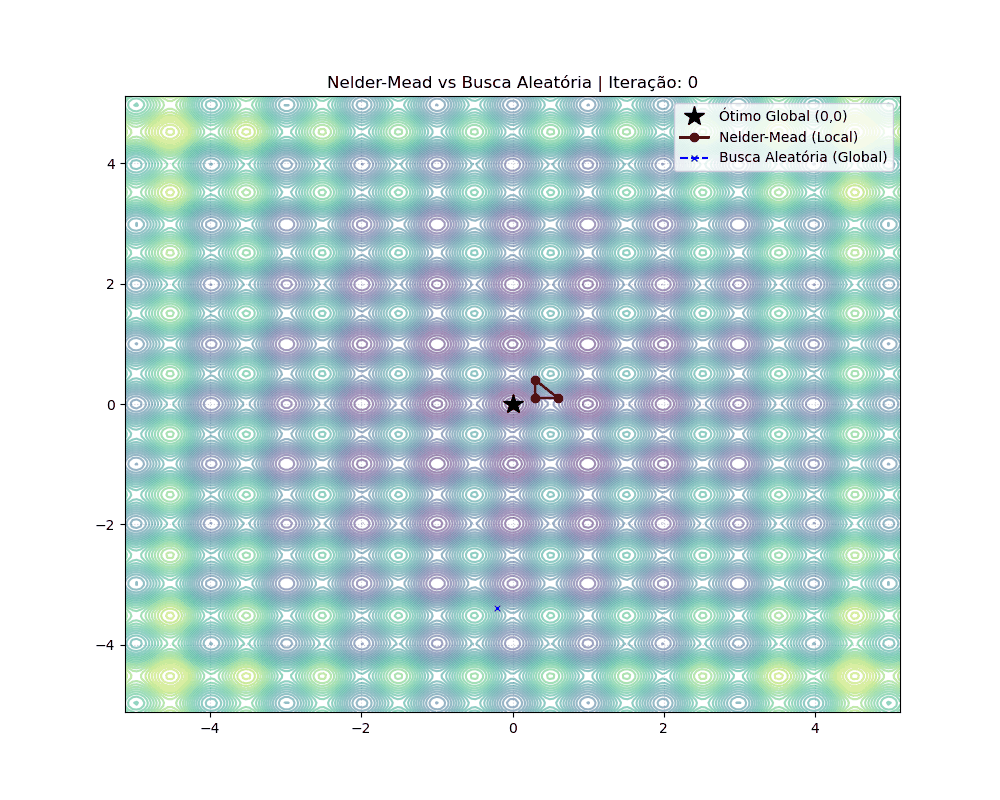

In [31]:
nome_arquivo = executar_e_plotar_animacao()
Image(filename=nome_arquivo)

#### Conclusões

**Pontos fortes do Nelder-Mead:**

- **Não usa derivadas:** precisa apenas dos valores da função objetivo, então pode ser aplicado a funções sem derivada.
- **Derivada muito complexa:** também é uma alternativa quando a derivada existe, mas é difícil de calcular.
- **Funções não lineares:** é indicado para funções objetivo não lineares, como a de Rastrigin.
- **Mínimo global não exigido:** é adequado quando um bom mínimo local é suficiente, pois o método não garante o mínimo global.

**Comparação com a busca aleatória:**

O Nelder-Mead anda com direção: a cada iteração, o pior vértice do simplex é trocado por um ponto melhor, e o método converge com precisão para o mínimo do vale em que o simplex foi colocado. No experimento, isso levou ao ótimo global $(0, 0)$; já com o simplex inicial de tamanho 0,9, o método parou em um mínimo local. A busca aleatória está mais para uma busca exploratória: sorteia pontos em todo o domínio, sem direção e sem precisão, e o seu resultado depende da sorte dos sorteios. Em compensação, por cobrir todo o espaço de busca, ela permite analisar o comportamento da função.